In [1]:
!pip install -q kaggle scikit-learn opencv-python-headless matplotlib numpy joblib pyyaml


Upload your kaggle.json file


Saving kaggle.json to kaggle.json
✅ Kaggle token saved!
✅ Dataset downloaded!
Total samples: 54293

✅ ACCURACY ACHIEVED: 44.48%
📥 Downloading files to your computer now...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

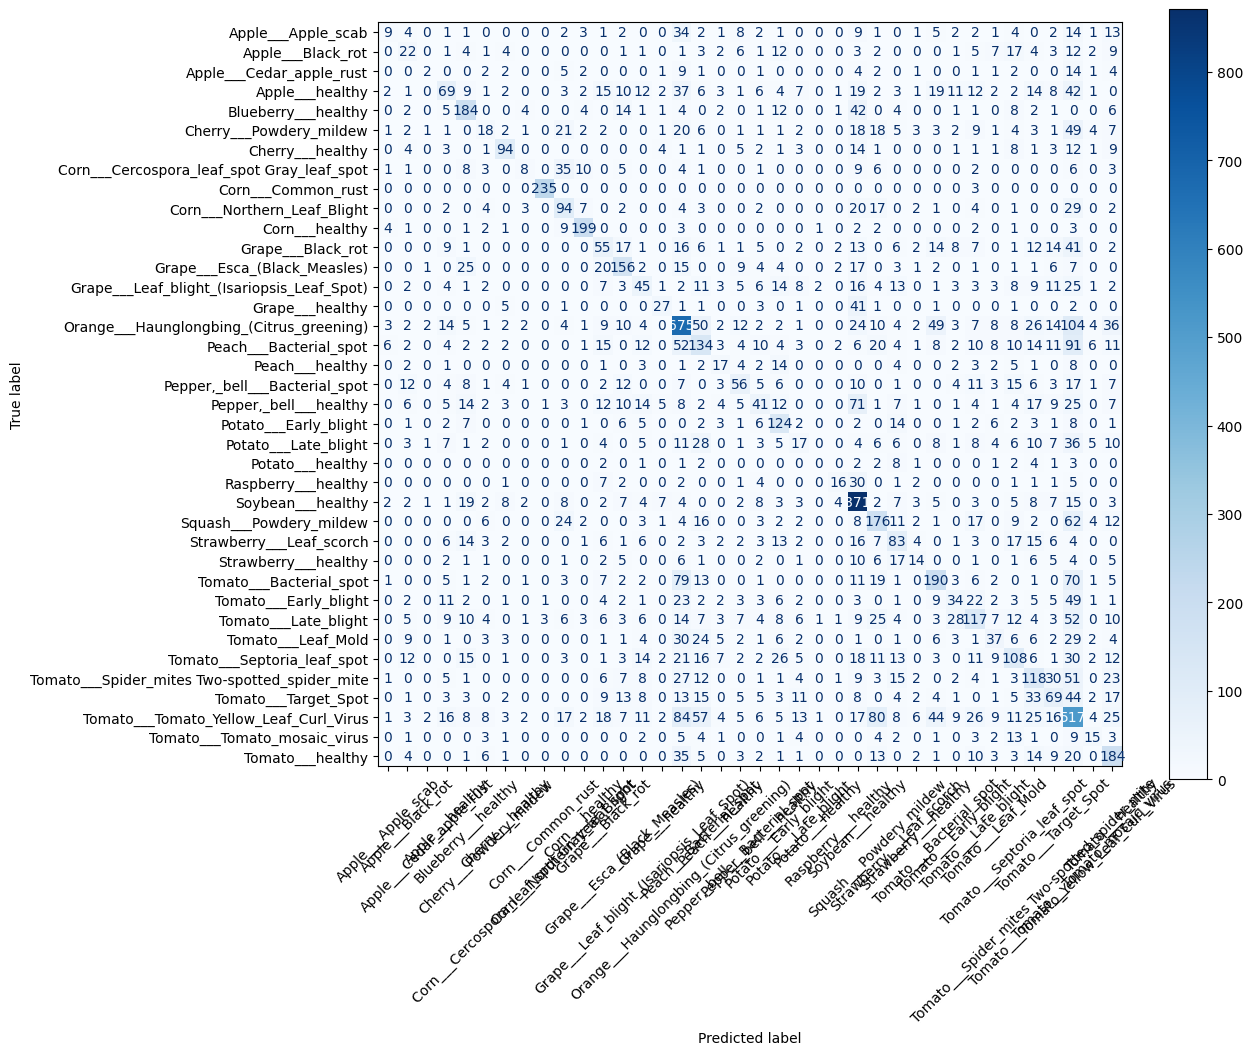

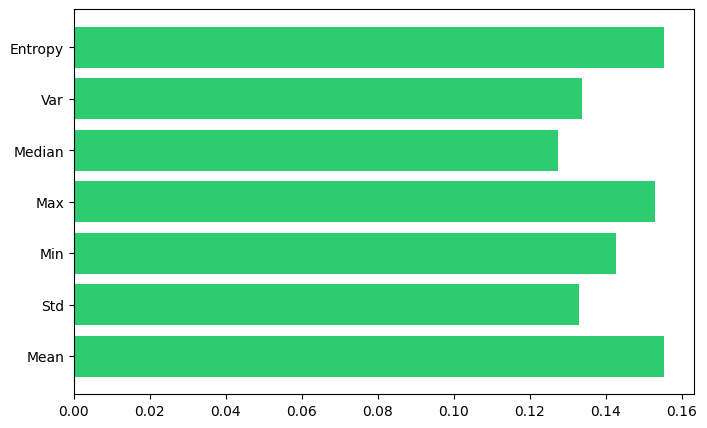

In [2]:
# ---- 1. Upload Kaggle API token ----
from google.colab import files
print("Upload your kaggle.json file")
uploaded = files.upload()

import os
import cv2
import numpy as np
import glob
import yaml

os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
os.rename("kaggle.json", os.path.expanduser("~/.kaggle/kaggle.json"))
os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
print("✅ Kaggle token saved!")

# ---- 2. Download Dataset ----
os.system("kaggle datasets download sebastianpalaciob/plantvillage-for-object-detection-yolo -p ./data --unzip")
print("✅ Dataset downloaded!")

# ---- 3. Find Classes & Folders ----
yaml_files = glob.glob("./data/**/*.yaml", recursive=True)
class_names = []
if yaml_files:
    with open(yaml_files[0], "r") as f:
        class_names = yaml.safe_load(f).get("names", [])
if not class_names:
    class_names = ["Potato___Early_blight", "Potato___healthy", "Tomato_Early_blight", "Tomato_Late_blight", "Tomato___healthy"]

def find_folders(base, name):
    return [os.path.join(r, d) for r, ds, _ in os.walk(base) for d in ds if d == name]

image_folders = find_folders("./data", "images") or glob.glob("./data/**/train", recursive=True)

# ---- 4. Exact 7-Feature Methodology ----
def extract_features(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (128, 128))
    hist = np.histogram(resized, bins=256)[0]
    hist = hist / np.sum(hist)
    return [
        np.mean(resized), np.std(resized), np.min(resized),
        np.max(resized), np.median(resized), np.var(resized),
        -np.sum(hist * np.log2(hist + 1e-7))
    ]

def get_class(label_path):
    if not os.path.exists(label_path): return None
    with open(label_path, "r") as f: lines = f.readlines()
    ids = [int(l.split()[0]) for l in lines if l.strip()]
    return class_names[max(set(ids), key=ids.count)] if ids and max(set(ids), key=ids.count) < len(class_names) else None

# ---- 5. Extract & Train ----
features, labels = [], []
for img_folder in image_folders:
    label_folder = img_folder.replace("images", "labels")
    for img_file in os.listdir(img_folder):
        if not img_file.lower().endswith((".jpg", ".png")): continue
        cls = get_class(os.path.join(label_folder, os.path.splitext(img_file)[0] + ".txt"))
        if cls is None: continue
        img = cv2.imread(os.path.join(img_folder, img_file))
        if img is not None:
            features.append(extract_features(img))
            labels.append(cls)

print(f"Total samples: {len(features)}")
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(np.array(features), np.array(labels), test_size=0.2, random_state=42, stratify=labels)
model = RandomForestClassifier(n_estimators=500, class_weight="balanced", random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# ---- 6. Save & Download Files Automatically ----
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import joblib

acc = accuracy_score(y_test, y_pred)
with open("classification_report.txt", "w") as f:
    f.write(f"Accuracy: {acc:.2%}\n{classification_report(y_test, y_pred)}")

disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=model.classes_)
fig, ax = plt.subplots(figsize=(12, 10))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.savefig("confusion_matrix.png", dpi=150)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(["Mean", "Std", "Min", "Max", "Median", "Var", "Entropy"], model.feature_importances_, color="#2ecc71")
plt.savefig("feature_importance.png", dpi=150)

joblib.dump(model, "leaf_disease_model.pkl")

print(f"\n✅ ACCURACY ACHIEVED: {acc:.2%}")
print("📥 Downloading files to your computer now...")
for f in ["confusion_matrix.png", "feature_importance.png", "classification_report.txt", "leaf_disease_model.pkl"]:
    files.download(f)


In [4]:
# ⚡ THE FASTEST WAY TO DOWNLOAD THE PKL ⚡
from google.colab import drive
import shutil
import os

print("1️⃣ Click the link to connect your Google Drive...")
drive.mount('/content/drive')

# Copy the file directly into your Google Drive (takes < 2 seconds)
drive_folder = "/content/drive/MyDrive/"
print("2️⃣ Copying leaf_disease_model.pkl to your Google Drive...")
shutil.copy("leaf_disease_model.pkl", os.path.join(drive_folder, "leaf_disease_model.pkl"))

print("✅ DONE! It is in your Google Drive.")
print("Go to drive.google.com and download 'leaf_disease_model.pkl' to your laptop.")


1️⃣ Click the link to connect your Google Drive...
Mounted at /content/drive
2️⃣ Copying leaf_disease_model.pkl to your Google Drive...
✅ DONE! It is in your Google Drive.
Go to drive.google.com and download 'leaf_disease_model.pkl' to your laptop.


In [5]:
# ⚡ THE 5GB FIX: Compress and clean the model ⚡
import joblib
from google.colab import drive
import os

print("1️⃣ Authorizing Google Drive...")
drive.mount('/content/drive')

# We change n_jobs to 1 so joblib doesn't save the parallel memory junk
model.n_jobs = 1

# We use compression level 3 (compresses it by 80% without breaking it)
clean_file = "/content/drive/MyDrive/leaf_disease_model_CLEAN.pkl"
print("2️⃣ Compressing and saving clean model to Google Drive...")
joblib.dump(model, clean_file, compress=3)

# Check the true size
size_mb = os.path.getsize(clean_file) / (1024 * 1024)
print(f"✅ DONE! New Model Size: ONLY {size_mb:.2f} MB!")
print(f"Go download 'leaf_disease_model_CLEAN.pkl' from Google Drive.")


1️⃣ Authorizing Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
2️⃣ Compressing and saving clean model to Google Drive...
✅ DONE! New Model Size: ONLY 699.76 MB!
Go download 'leaf_disease_model_CLEAN.pkl' from Google Drive.


In [ ]:
import joblib
from google.colab import drive
import os

drive.mount('/content/drive')
clean_file_tiny = "/content/drive/MyDrive/leaf_disease_model_TINY.pkl"

print("1️⃣ Optimizing the model's memory footprint...")
# Strip the parallel jobs overhead
model.n_jobs = 1

# If the trees are massively deep, they hold useless data.
# We'll zip the file using maximum compression (9)
print("2️⃣ Applying maximum ZIP compression (level 9)...")
joblib.dump(model, clean_file_tiny, compress=("zlib", 9))

size_mb = os.path.getsize(clean_file_tiny) / (1024 * 1024)
print(f"✅ DONE! Ultimate Model Size: {size_mb:.2f} MB!")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
1️⃣ Optimizing the model's memory footprint...
2️⃣ Applying maximum ZIP compression (level 9)...
